In [ ]:
# base_financeiro

import pandas as pd
import numpy as np

caminho_completo = '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/extracao_bases/bases_baixadas/base_financeiro.csv'

df = pd.read_csv(caminho_completo) 

colunas_days = [col for col in df.columns if 'DAYS' in col]

df[colunas_days] = df[colunas_days].mask(df[colunas_days] > 0, np.nan)

print("--- Resultado após a limpeza ---")
print(df[['SK_ID_CURR'] + colunas_days].head())

caminho_salvar = '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/extracao_bases/bases_baixadas/base_financeiro_limpa.csv'
df.to_csv(caminho_salvar, index=False)

print("\nPlanilha limpa salva com sucesso como 'base_financeiro_limpa.csv'!")

In [ ]:
# base_infos_pessoais

import pandas as pd
import numpy as np

caminho_completo = '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/extracao_bases/bases_baixadas/base_infos_pessoais.csv'
df_novo = pd.read_csv(caminho_completo)

df_novo.loc[df_novo['DAYS_BIRTH'] >= 0, 'DAYS_BIRTH'] = np.nan

mask_single = df_novo['NAME_FAMILY_STATUS'] == 'Single / Not Married'
df_novo.loc[mask_single, 'CNT_CHILDREN'] = 0
df_novo.loc[mask_single, 'CNT_FAM_MEMBERS'] = 1 + df_novo.loc[mask_single, 'CNT_CHILDREN']

mask_married = df_novo['NAME_FAMILY_STATUS'].isin(['Married', 'Civil Marriage'])
df_novo.loc[mask_married, 'CNT_FAM_MEMBERS'] = 2 + df_novo.loc[mask_married, 'CNT_CHILDREN']

df_novo.loc[df_novo['DAYS_BIRTH'] >= -6574, 'DAYS_BIRTH'] = np.nan

mask_higher = (df_novo['NAME_EDUCATION_TYPE'] == 'Higher education') & (df_novo['DAYS_BIRTH'] > -7665)
df_novo.loc[mask_higher, 'DAYS_BIRTH'] = np.nan

colunas_verificacao = ['DAYS_BIRTH', 'NAME_FAMILY_STATUS', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'NAME_EDUCATION_TYPE']
print("--- Amostra após a limpeza lógica ---")
print(df_novo[colunas_verificacao].head(10))

caminho_salvar = '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/extracao_bases/bases_baixadas/base_infos_pessoais_limpa.csv'

df_novo.to_csv(caminho_salvar, index=False)

print("\nSucesso! Planilha limpa salva como 'base_infos_pessoais_limpa.csv'.")

In [ ]:
# base_regional
import pandas as pd
import numpy as np

# 1. CARREGANDO A PLANILHA REGIONAL
caminho_regional = '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/extracao_bases/bases_baixadas/base_regional.csv'
df_regional = pd.read_csv(caminho_regional)

# --------------------------------------------------------------------------------
# ETAPA 1: Colunas que devem estar entre 0 e 1 (Normalizadas)
# --------------------------------------------------------------------------------
colunas_0_1 = [
    'REGION_POPULATION_RELATIVE', 
    'APARTMENTS_AVG', 
    'YEARS_BEGINEXPLUATATION_AVG', 
    'ELEVATORS_AVG'
]

for col in colunas_0_1:
    # Se o valor for menor que 0 OU maior que 1, transformamos em NaN
    df_regional[col] = df_regional[col].mask((df_regional[col] < 0) | (df_regional[col] > 1), np.nan)

# --------------------------------------------------------------------------------
# ETAPA 2: Rating da Região (Deve ser entre 1 e 3)
# --------------------------------------------------------------------------------
col_rating = 'REGION_RATING_CLIENT_W_CITY'
# Se o rating for menor que 1 OU maior que 3, transformamos em NaN
df_regional[col_rating] = df_regional[col_rating].mask((df_regional[col_rating] < 1) | (df_regional[col_rating] > 3), np.nan)

# --------------------------------------------------------------------------------
# ETAPA 3: SALVANDO O RESULTADO
# --------------------------------------------------------------------------------
caminho_salvar = '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/extracao_bases/bases_baixadas/base_regional_limpa.csv'
df_regional.to_csv(caminho_salvar, index=False)

# --- Verificação final no terminal ---
print("=== Relatório de Limpeza (Base Regional) ===")
print(f"Intervalo esperado 0-1:\n{df_regional[colunas_0_1].agg(['min', 'max'])}")
print(f"\nIntervalo esperado 1-3 em Rating:\nMin: {df_regional[col_rating].min()} | Max: {df_regional[col_rating].max()}")
print(f"\nArquivo salvo em: {caminho_salvar}")

In [ ]:
# base_scores
import pandas as pd
import numpy as np

# 1. CARREGANDO A BASE DE SCORES
path_scores = '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/extracao_bases/bases_baixadas/base_scores.csv'
df_scores = pd.read_csv(path_scores)

# --------------------------------------------------------------------------------
# ETAPA 1: Scores Externos (Devem estar entre 0 e 1)
# --------------------------------------------------------------------------------
cols_ext = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

for col in cols_ext:
    # Anula se for menor que 0 OU maior que 1
    df_scores[col] = df_scores[col].mask((df_scores[col] < 0) | (df_scores[col] > 1), np.nan)

# --------------------------------------------------------------------------------
# ETAPA 2: Mudança de Telefone (Deve ser < 0)
# --------------------------------------------------------------------------------
# Se for maior ou igual a 0, transformamos em NaN
df_scores['DAYS_LAST_PHONE_CHANGE'] = df_scores['DAYS_LAST_PHONE_CHANGE'].mask(df_scores['DAYS_LAST_PHONE_CHANGE'] >= 0, np.nan)

# --------------------------------------------------------------------------------
# ETAPA 3: SALVANDO O RESULTADO
# --------------------------------------------------------------------------------
caminho_salvar = '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/extracao_bases/bases_baixadas/base_scores_limpa.csv'
df_scores.to_csv(caminho_salvar, index=False)

print("Base de scores processada e salva com sucesso!")
print(df_scores[cols_ext + ['DAYS_LAST_PHONE_CHANGE']].head())

In [ ]:
# fazendo o merge
import pandas as pd

# 1. Definindo os caminhos das bases limpas
paths = [
    '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/tratamento_bases/bases_limpas/base_bens_limpa.csv',
    '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/tratamento_bases/bases_limpas/base_financeiro_limpa.csv',
    '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/tratamento_bases/bases_limpas/base_infos_pessoais_limpa.csv',
    '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/tratamento_bases/bases_limpas/base_regional_limpa.csv',
    '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/tratamento_bases/bases_limpas/base_scores_limpa.csv',
    '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/tratamento_bases/bases_limpas/base_target_limpa.csv'
]

# 2. Carregando a primeira base para iniciar o "esqueleto" do dataframe final
df_final = pd.read_csv(paths[0])

# 3. Loop para ler e juntar as outras 5 bases
for path in paths[1:]:
    df_proximo = pd.read_csv(path)
    
    # Fazemos o merge usando o SK_ID_CURR. 
    # O how='left' garante que manteremos todos os IDs da base principal.
    df_final = pd.merge(df_final, df_proximo, on='SK_ID_CURR', how='left')

# 4. Verificação final
print(f"Junção concluída!")
print(f"Quantidade total de colunas: {df_final.shape[1]}")
print(f"Quantidade total de linhas: {df_final.shape[0]}")

# 5. Salvar o Dataset mestre unificado
caminho_salvar = '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/tratamento_bases/bases_limpas/dataset_completo_unificado.csv'
df_final.to_csv(caminho_salvar, index=False)

print(f"\nArquivo mestre salvo em: {caminho_salvar}")

In [ ]:
# Verificando se existem IDs duplicados

import pandas as pd

# Caminho do seu arquivo unificado
caminho_unificado = '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/tratamento_bases/bases_limpas/dataset_completo_unificado.csv'

# Carregando a base
df_final = pd.read_csv(caminho_unificado)

# 1. Contando o total de duplicados
total_duplicados = df_final['SK_ID_CURR'].duplicated().sum()

# 2. Mostrando o resultado
print(f"Relatório de Duplicidade:")
print(f"- Total de linhas na base: {len(df_final)}")
print(f"- IDs únicos encontrados: {df_final['SK_ID_CURR'].nunique()}")
print(f"- Quantidade de IDs duplicados: {total_duplicados}")

# 3. Caso existam duplicados, listar quais são (opcional)
if total_duplicados > 0:
    print("\nExemplos de IDs que aparecem mais de uma vez:")
    # Mostra os IDs duplicados e quantas vezes cada um aparece
    contagem = df_final['SK_ID_CURR'].value_counts()
    print(contagem[contagem > 1].head(10))
else:
    print("\nParabéns! Não existem IDs duplicados na coluna SK_ID_CURR.")

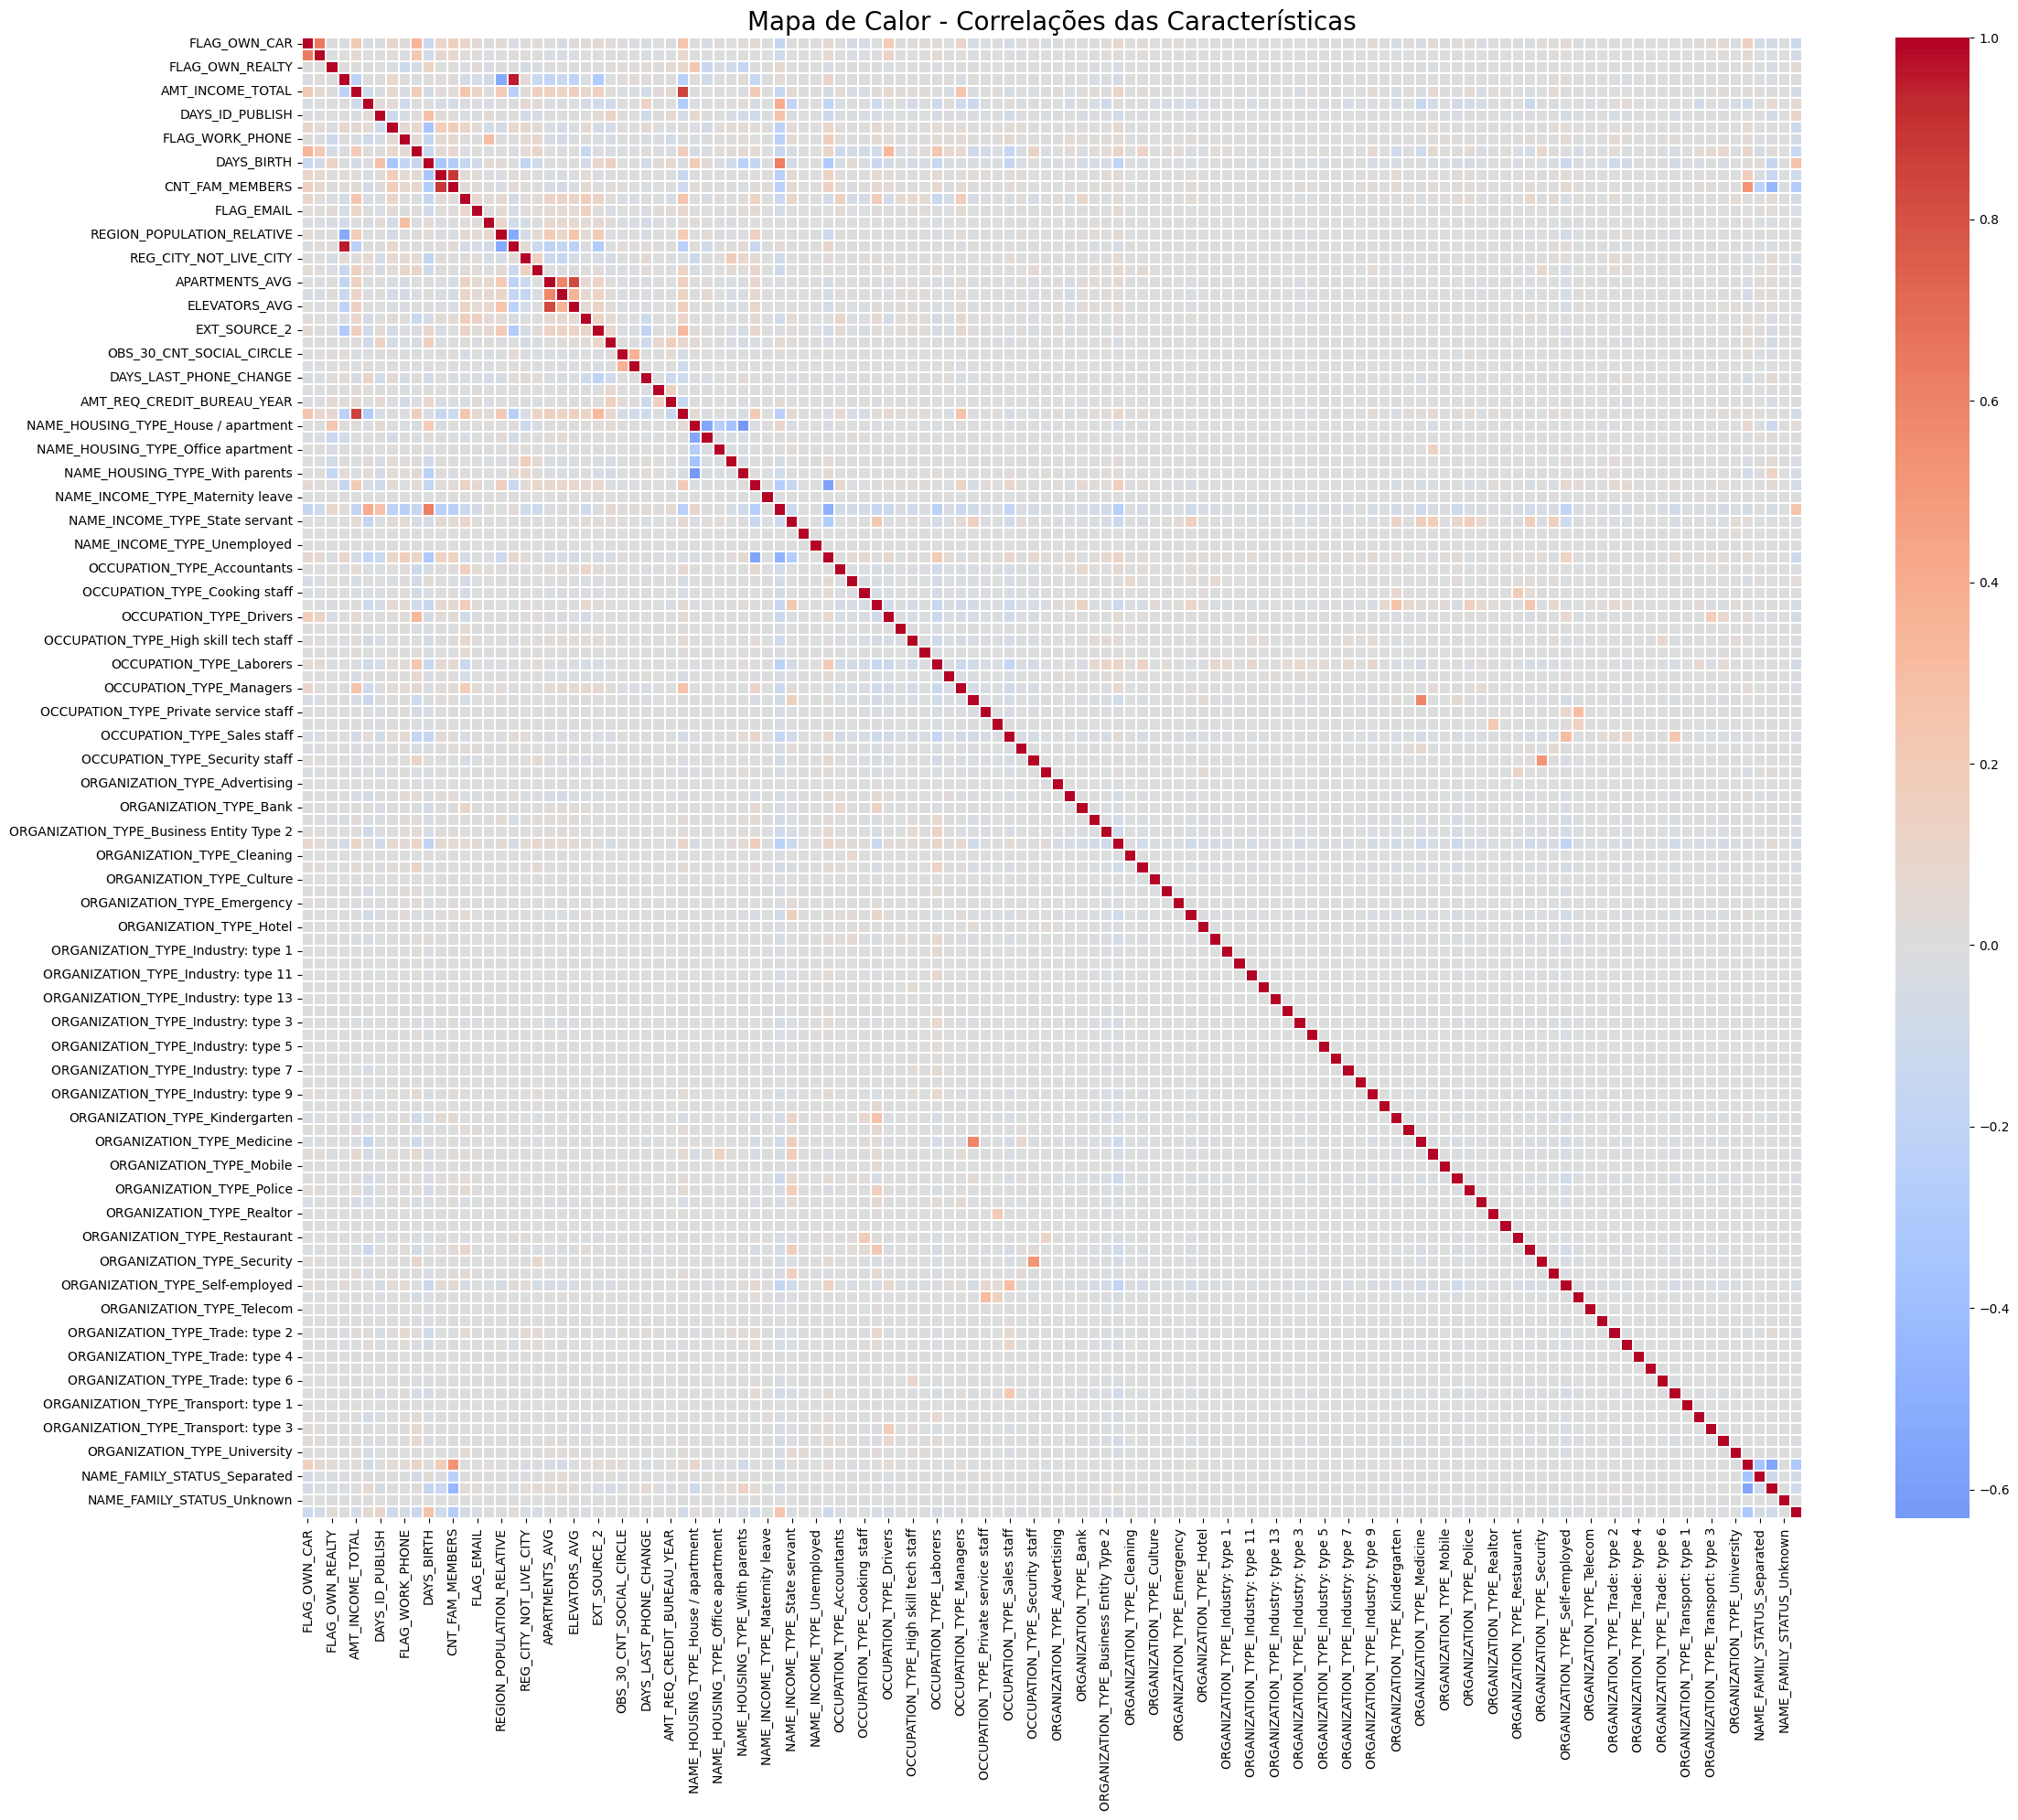


O Dataset agora possui 124 colunas.
Gráfico de calor gerado e salvo como 'mapa_de_calor_correlacoes.png'!

--- ANÁLISE DO ALVO: TARGET_CREDIT_LIMIT ---

[ TOP 10 Características que MAIS AUMENTAM o Limite ]
AMT_INCOME_TOTAL                         0.858399
EXT_SOURCE_2                             0.318199
OCCUPATION_TYPE_Managers                 0.262230
FLAG_OWN_CAR                             0.247126
NAME_EDUCATION_TYPE                      0.236281
NAME_INCOME_TYPE_Commercial associate    0.202932
REGION_POPULATION_RELATIVE               0.200699
CODE_GENDER                              0.171251
ELEVATORS_AVG                            0.158688
APARTMENTS_AVG                           0.150785
Name: TARGET_CREDIT_LIMIT, dtype: float64

[ TOP 10 Características que MAIS DIMINUEM o Limite ]
NAME_FAMILY_STATUS_Widow      -0.071483
DAYS_LAST_PHONE_CHANGE        -0.090696
DEF_30_CNT_SOCIAL_CIRCLE      -0.098639
CNT_FAM_MEMBERS               -0.110566
AMT_REQ_CREDIT_BUREAU_YEAR    -0.15

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Carregar o dataset
caminho_arquivo = '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/tratamento_bases/bases_limpas/dataset_completo_unificado.csv'
df = pd.read_csv(caminho_arquivo)

# Substituir 'XNA' por 0 em todo o dataset para evitar erro de conversão
df = df.replace('XNA', 0)

# 2. Excluir a primeira coluna (SK_ID_CURR)
if 'SK_ID_CURR' in df.columns:
    df = df.drop(columns=['SK_ID_CURR'])

# 3. Substituir Yes/No (ou Y/N) por 0 e 1 nas colunas de carro e imóvel
df['FLAG_OWN_CAR'] = df['FLAG_OWN_CAR'].replace({'Y': 1, 'N': 0, 'Yes': 1, 'No': 0})
df['FLAG_OWN_REALTY'] = df['FLAG_OWN_REALTY'].replace({'Y': 1, 'N': 0, 'Yes': 1, 'No': 0})

# 4. Substituir Gênero por 0 e 1
df['CODE_GENDER'] = df['CODE_GENDER'].replace({'M': 1, 'F': 0, 'Male': 1, 'Female': 0})

# 5. Mapear a coluna de Educação (Ordinal Encoding)
mapeamento_educacao = {
    'Lower secondary': 1,
    'Secondary / secondary special': 2,
    'Incomplete higher': 3,
    'Higher education': 4
}
df['NAME_EDUCATION_TYPE'] = df['NAME_EDUCATION_TYPE'].map(mapeamento_educacao)

# 6. Substituir todas as células em branco (NaN) por 0
df = df.fillna(0)

# 7. Realizar One-Hot Encoding nas colunas categóricas (criando as colunas Dummies)
colunas_para_dummy = [
    'NAME_HOUSING_TYPE', 
    'NAME_INCOME_TYPE', 
    'OCCUPATION_TYPE', 
    'ORGANIZATION_TYPE', 
    'NAME_FAMILY_STATUS'
]
df = pd.get_dummies(df, columns=colunas_para_dummy, drop_first=True)

# 8. Deixar os números positivos nas colunas de dias (usando valor absoluto)
df['DAYS_ID_PUBLISH'] = df['DAYS_ID_PUBLISH'].abs()
df['DAYS_BIRTH'] = df['DAYS_BIRTH'].abs()

# ==========================================
# GERAÇÃO DO GRÁFICO DE CALOR (HEATMAP)
# ==========================================

# Calcula a matriz de correlação
matriz_correlacao = df.corr()

# Configura o tamanho da figura
plt.figure(figsize=(24, 20))

# Cria o heatmap
sns.heatmap(
    matriz_correlacao, 
    annot=False,        
    cmap='coolwarm',    
    center=0,           
    linewidths=0.1      
)

plt.title('Mapa de Calor - Correlações das Características', fontsize=20)
plt.tight_layout() 

# Salva e exibe o gráfico
plt.savefig('mapa_de_calor_correlacoes.png', dpi=300)
plt.show()

print(f"\nO Dataset agora possui {df.shape[1]} colunas.")
print("Gráfico de calor gerado e salvo como 'mapa_de_calor_correlacoes.png'!")

# ==========================================
# ANÁLISE DA VARIÁVEL ALVO (LIMITE DE CRÉDITO)
# ==========================================
# Captura o nome da última coluna do dataset processado
coluna_alvo = 'TARGET_CREDIT_LIMIT'
print(f"\n--- ANÁLISE DO ALVO: {coluna_alvo} ---")

# Isola as correlações apenas do alvo e ordena do maior para o menor
correlacoes_limite = matriz_correlacao[coluna_alvo].sort_values(ascending=False)

print("\n[ TOP 10 Características que MAIS AUMENTAM o Limite ]")
# Usamos [1:11] para pular a primeira linha (que é a correlação do limite com ele mesmo, que é 1.0)
print(correlacoes_limite[1:11]) 

print("\n[ TOP 10 Características que MAIS DIMINUEM o Limite ]")
print(correlacoes_limite.tail(10))

# ==========================================
# SALVAMENTO E PREPARAÇÃO PARA O MODELO
# ==========================================

# Salva o resultado final em um novo arquivo CSV
df.to_csv('dataset_processado_para_modelo.csv', index=False)
print("\nNova planilha salva com sucesso: 'dataset_processado_para_modelo.csv'")

# Separa os dados em X (Características) e y (Gabarito/Alvo)
X = df.drop(columns=[coluna_alvo])
y = df[coluna_alvo]

print(f"\n--- DADOS PRONTOS PARA O TREINAMENTO ---")
print(f"Características (X) separadas com sucesso: {X.shape[1]} colunas.")
print(f"Gabarito (y) separado com sucesso: {y.shape[0]} registros.")